Data taken from:
https://www.kaggle.com/datasets/xvivancos/star-wars-movie-scripts

In [36]:
# import bpe library

from tokenizers import Tokenizer
from tokenizers.models import BPE, WordPiece, Unigram
from tokenizers.processors import BertProcessing
from tokenizers.trainers import BpeTrainer, WordPieceTrainer, UnigramTrainer
from tokenizers.pre_tokenizers import Whitespace

In [37]:
# create tokenizer & set files & train

bpe_tokenizer = Tokenizer(BPE())

# used to break down into words before tokenizing, can be turned off
bpe_tokenizer.pre_tokenizer = Whitespace() 

bpe_trainer = BpeTrainer(vocab_size=1000)
files = ['episodeIV_cleaned.txt','episodeV_cleaned.txt','episodeVI_cleaned.txt']

# train file
bpe_tokenizer.train(files, bpe_trainer)


In [38]:
wordpiece_tokenizer = Tokenizer(WordPiece())

wordpiece_tokenizer.pre_tokenizer = Whitespace()
wordpiece_trainer = WordPieceTrainer(vocab_size=1000, 
                                    special_tokens=["[UNK]", "[SEP]", "[PAD]", "[CLS]", "[MASK]"],
                                    min_frequency=2)
wordpiece_tokenizer.train(files, wordpiece_trainer)

In [39]:
unigram_tokenizer = Tokenizer(Unigram())
unigram_tokenizer.pre_tokenizer = Whitespace()
unigram_trainer = UnigramTrainer(vocab_size=1000, special_tokens=["[UNK]", "[SEP]", "[PAD]", "[CLS]", "[MASK]"])
unigram_tokenizer.train(files, unigram_trainer)

In [40]:
# make things pretty to output
from colorama import Fore, Style

def pretty_print_token_and_ids(tokenized):
    colors = [Fore.RED, Fore.GREEN, Fore.YELLOW, Fore.BLUE, Fore.MAGENTA, Fore.CYAN]
    for i, (tok, idx) in enumerate(zip(tokenized.tokens, tokenized.ids)):
        color = colors[i % len(colors)]
        print(f"{color}{tok} ({idx}){Style.RESET_ALL}", end=" ")

def pretty_print_tokens(tokenized):
    colors = [Fore.RED, Fore.GREEN, Fore.YELLOW, Fore.BLUE, Fore.MAGENTA, Fore.CYAN]
    for i, (tok, idx) in enumerate(zip(tokenized.tokens, tokenized.ids)):
        color = colors[i % len(colors)]
        print(f"{color}{tok}{Style.RESET_ALL}", end=" ")

In [41]:
# print and toy with results

bpe_output = bpe_tokenizer.encode("now what in the tarnation Vader? where did that lightsaber come from?")
pretty_print_tokens(bpe_output)

# not as pretty printing
# print(bpe_output.tokens)



now what in the t ar n ation Vader ? where did that light s ab er come from ? 

In [ ]:
wordpiece_output = wordpiece_tokenizer.encode("now what in the tarnation Vader? where did that lightsaber come from?")
pretty_print_tokens(wordpiece_output)   

now what in the t ##ar ##na ##t ##ion Vader ? where did that light ##s ##ab ##er come from ? 

The "#" are indicating a subword continuation. Tarnation was split into 5 subwords, probably because that word never appears in the text. 

In [43]:
unigram_output = unigram_tokenizer.encode("now what in the tarnation Vader? where did that lightsaber come from?")
pretty_print_tokens(unigram_output)

now what in the t ar n ation V ader ? where did that light s ab er come fro m ? 

Tarnation is also split into 5 subwords for unigram as well. Same with saber. 

### Weird discovery: 
When printing out the tokenization of lightsaber by using BPE encoding and a vocab size of 1000, we noticed that "lightsaber" was broken down into `['light', 's', 'ab', 'er']`

Trying `[cntr]+F` we found that there are only 4 times the word is spoken in the original Star Wars trilogy: once in Episode IV and three times in Episode VI.

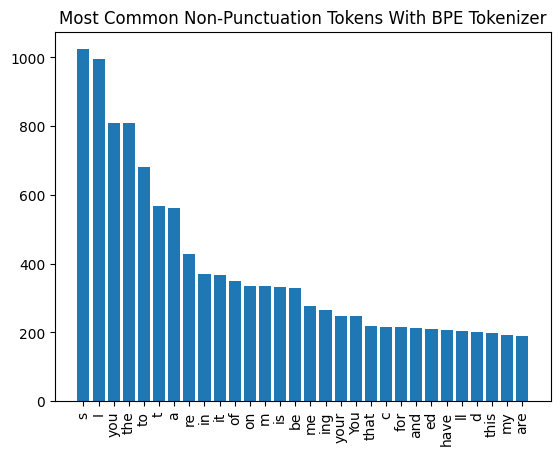

In [59]:
from collections import Counter
import matplotlib.pyplot as plt
import re

all_tokens = []
for ep_num in ['IV','V','VI']:
    with open(f'episode{ep_num}_cleaned.txt') as f:
        for line in f:
            enc = bpe_tokenizer.encode(line.strip())
            all_tokens.extend(enc.tokens)

word_tokens = [t for t in all_tokens if re.search(r'\w', t)]

counts = Counter(word_tokens).most_common(30)
tokens, freqs = zip(*counts)

plt.bar(tokens,freqs)
plt.xticks(rotation=90)
plt.title("Most Common Non-Punctuation Tokens With BPE Tokenizer")
plt.show()


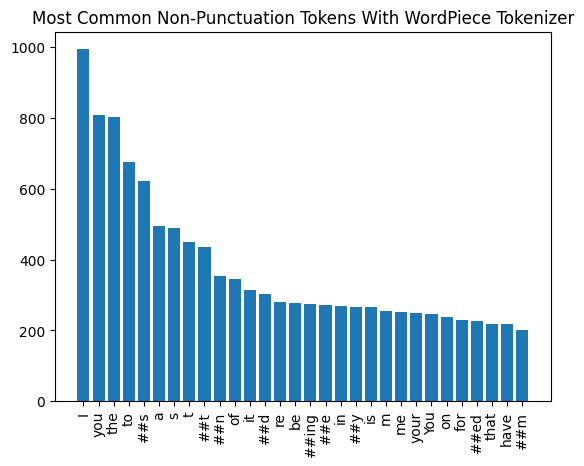

In [60]:
from collections import Counter
import matplotlib.pyplot as plt
import re

all_tokens = []
for ep_num in ['IV','V','VI']:
    with open(f'episode{ep_num}_cleaned.txt') as f:
        for line in f:
            enc = wordpiece_tokenizer.encode(line.strip())
            all_tokens.extend(enc.tokens)

word_tokens = [t for t in all_tokens if re.search(r'\w', t)]

counts = Counter(word_tokens).most_common(30)
tokens, freqs = zip(*counts)

plt.bar(tokens,freqs)
plt.xticks(rotation=90)
plt.title("Most Common Non-Punctuation Tokens With WordPiece Tokenizer")
plt.show()


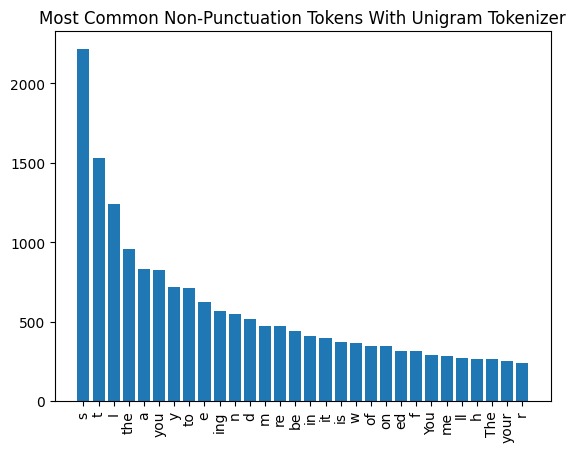

In [61]:
from collections import Counter
import matplotlib.pyplot as plt
import re

all_tokens = []
for ep_num in ['IV','V','VI']:
    with open(f'episode{ep_num}_cleaned.txt') as f:
        for line in f:
            enc = unigram_tokenizer.encode(line.strip())
            all_tokens.extend(enc.tokens)

word_tokens = [t for t in all_tokens if re.search(r'\w', t)]

counts = Counter(word_tokens).most_common(30)
tokens, freqs = zip(*counts)

plt.bar(tokens,freqs)
plt.xticks(rotation=90)
plt.title("Most Common Non-Punctuation Tokens With Unigram Tokenizer")
plt.show()


It is interesting how all 3 methods have alot of single characters as tokens, specifically "s", "t", "a". It probably has to do with the small amount of training data available. 

For a little more exploration we found the most commonly spoken names using the token count from BPE encoding 

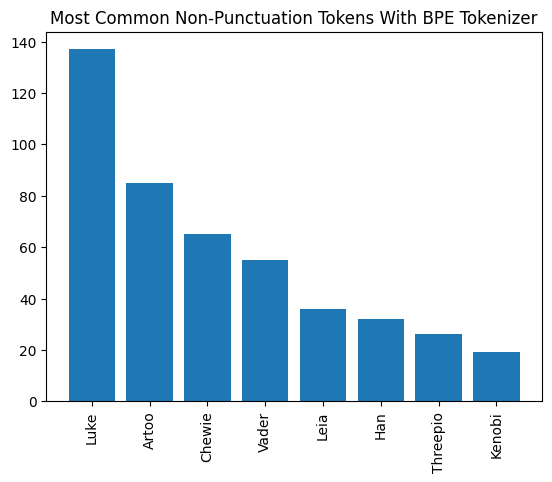

In [ ]:
# most commonly named characters 

common_names = ['Luke', 'Han', 'Leia', 'Artoo', 'Threepio', 'Kenobi', 'Chewie', 'Vader', 'Palpatine']

all_tokens = []
for ep_num in ['IV','V','VI']:
    with open(f'episode{ep_num}_cleaned.txt') as f:
        for line in f:
            enc = bpe_tokenizer.encode(line.strip())
            all_tokens.extend(enc.tokens)

name_tokens = [t for t in all_tokens if t in common_names]

counts = Counter(name_tokens).most_common(10)
tokens, freqs = zip(*counts)

plt.bar(tokens,freqs)
plt.xticks(rotation=90)
plt.title("Most Commonly Spoken Names")
plt.show()

We end by leaving an interactive tool to see the breakdown of tokens and their respective ids for any given input.

In [64]:
def pretty_print_by_encoding_scheme(encoder, input, print_with_tokens=False):
    match encoder:
        case 'bpe':
            tokens_to_print = bpe_tokenizer.encode(input)
        case 'wordpiece':
            tokens_to_print = wordpiece_tokenizer.encode(input)
        case 'unigram':
            tokens_to_print = unigram_tokenizer.encode(input)

    if print_with_tokens:
        pretty_print_token_and_ids(tokens_to_print)
    else:    
        pretty_print_tokens(tokens_to_print)

In [68]:
# edit the "input_string" and choose options for pretty_print_by_encoding_scheme
#    OPTIONS: 
#       encoder = 'bpe', 'wordpiece', or 'unigram'
#       print_with_tokens = True or False
#       input = 'your input string here'

encoder = 'unigram'
print_with_tokens = True
input_string = 'your chance to play with tokens and colors'

pretty_print_by_encoding_scheme(encoder=encoder, print_with_tokens=print_with_tokens, input=input_string)

your (39) chance (565) to (16) play (648) with (79) to (16) ke (53) n (22) s (6) and (48) col (636) or (67) s (6) 